In [1]:
# 1. Imports & Config
import re
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("eliasdabbas/web-server-access-logs")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/datasets/eliasdabbas/web-server-access-logs


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/eliasdabbas/web-server-access-logs"):
    print("ROOT:", root)
    print("FILES:", files)
    print("-" * 60)


ROOT: /kaggle/input/datasets/eliasdabbas/web-server-access-logs
FILES: ['access.log', 'client_hostname.csv']
------------------------------------------------------------


In [4]:
# 2. Data Loading & Parsing

path = "/kaggle/input/datasets/eliasdabbas/web-server-access-logs/access.log"

LOG_PATTERN = (
    r'(?P<ip>\S+)\s+'
    r'(?P<ident>\S+)\s+'
    r'(?P<user>\S+)\s+'
    r'\[(?P<time>[^\]]+)\]\s+'
    r'"(?P<method>\S+)\s+'
    r'(?P<url>\S+)\s+'
    r'(?P<protocol>[^"]+)"\s+'
    r'(?P<status>\d{3})\s+'
    r'(?P<bytes>\S+)'
)

rows = []
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        m = re.match(LOG_PATTERN, line)
        if m:
            rows.append(m.groupdict())

df = pd.DataFrame(rows)
print("Parsed shape:", df.shape)
df.head()


Parsed shape: (10365077, 9)


,ip,ident,user,time,method,url,protocol,status,bytes
0,54.36.149.41,-,-,22/Jan/2019:03:56:14 +0330,GET,/filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C...,HTTP/1.1,200,30577
1,31.56.96.51,-,-,22/Jan/2019:03:56:16 +0330,GET,/image/60844/productModel/200x200,HTTP/1.1,200,5667
2,31.56.96.51,-,-,22/Jan/2019:03:56:16 +0330,GET,/image/61474/productModel/200x200,HTTP/1.1,200,5379
3,40.77.167.129,-,-,22/Jan/2019:03:56:17 +0330,GET,/image/14925/productModel/100x100,HTTP/1.1,200,1696
4,91.99.72.15,-,-,22/Jan/2019:03:56:17 +0330,GET,/product/31893/62100/%D8%B3%D8%B4%D9%88%D8%A7%...,HTTP/1.1,200,41483


In [5]:
df["status"] = pd.to_numeric(df["status"], errors="coerce").fillna(0).astype(int)
df["bytes"] = pd.to_numeric(df["bytes"].replace("-", 0), errors="coerce").fillna(0).astype(int)

df["time"] = pd.to_datetime(
    df["time"],
    format="%d/%b/%Y:%H:%M:%S %z",
    errors="coerce"
)
df = df.dropna(subset=["time"])

df["date"] = df["time"].dt.date
df["hour"] = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.day_name()

df["path"] = df["url"].str.split("?", n=1).str[0]
df["user_id"] = df["ip"]

df["is_error"] = (df["status"] >= 400).astype(int)

df.shape, df.head()


((10365077, 15),
               ip ident user                      time method  \
 0   54.36.149.41     -    - 2019-01-22 03:56:14+03:30    GET   
 1    31.56.96.51     -    - 2019-01-22 03:56:16+03:30    GET   
 2    31.56.96.51     -    - 2019-01-22 03:56:16+03:30    GET   
 3  40.77.167.129     -    - 2019-01-22 03:56:17+03:30    GET   
 4    91.99.72.15     -    - 2019-01-22 03:56:17+03:30    GET   
 
                                                  url  protocol  status  bytes  \
 0  /filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C...  HTTP/1.1     200  30577   
 1                  /image/60844/productModel/200x200  HTTP/1.1     200   5667   
 2                  /image/61474/productModel/200x200  HTTP/1.1     200   5379   
 3                  /image/14925/productModel/100x100  HTTP/1.1     200   1696   
 4  /product/31893/62100/%D8%B3%D8%B4%D9%88%D8%A7%...  HTTP/1.1     200  41483   
 
          date  hour dayofweek  \
 0  2019-01-22     3   Tuesday   
 1  2019-01-22     3   Tuesda

In [6]:
# 3. Sessionization

df = df.sort_values(["user_id", "time"])

session_timeout = pd.Timedelta(minutes=30)

df["prev_time"] = df.groupby("user_id")["time"].shift()
df["time_diff"] = df["time"] - df["prev_time"]
df["new_session"] = (df["time_diff"] > session_timeout) | df["time_diff"].isna()

df["session_id"] = df.groupby("user_id")["new_session"].cumsum()

df[["user_id", "time", "path", "session_id"]].head()


,user_id,time,path,session_id
8354182,1.132.107.223,2019-01-26 02:26:22+03:30,/m/article/616/%D8%B9%D9%84%D8%AA-%D8%AE%D9%88...,1
8354187,1.132.107.223,2019-01-26 02:26:23+03:30,/settings/logo,1
8354190,1.132.107.223,2019-01-26 02:26:24+03:30,/amp-helper-frame.html,1
8354200,1.132.107.223,2019-01-26 02:26:25+03:30,/static/images/guarantees/bestPrice.png,1
8354201,1.132.107.223,2019-01-26 02:26:25+03:30,/static/images/guarantees/goodShopping.png,1


In [7]:
sessions = (
    df.groupby(["user_id", "session_id"])
    .agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        num_requests=("path", "size"),
        unique_paths=("path", "nunique"),
        num_errors=("is_error", "sum"),
    )
    .reset_index()
)

sessions["duration_sec"] = (sessions["end_time"] - sessions["start_time"]).dt.total_seconds()
sessions["error_rate"] = sessions["num_errors"] / sessions["num_requests"].replace(0, 1)

sessions.shape, sessions.head()


((337963, 9),
          user_id  session_id                start_time  \
 0  1.132.107.223           1 2019-01-26 02:26:22+03:30   
 1  1.132.108.133           1 2019-01-24 13:28:02+03:30   
 2   1.136.111.52           1 2019-01-23 04:47:33+03:30   
 3   1.158.74.178           1 2019-01-23 06:42:56+03:30   
 4  1.159.185.202           1 2019-01-26 17:48:09+03:30   
 
                    end_time  num_requests  unique_paths  num_errors  \
 0 2019-01-26 02:51:45+03:30            15            15           0   
 1 2019-01-24 13:28:02+03:30             1             1           0   
 2 2019-01-23 04:47:33+03:30             1             1           0   
 3 2019-01-23 06:44:29+03:30            37            30           1   
 4 2019-01-26 17:48:09+03:30             1             1           0   
 
    duration_sec  error_rate  
 0        1523.0    0.000000  
 1           0.0    0.000000  
 2           0.0    0.000000  
 3          93.0    0.027027  
 4           0.0    0.000000  )

In [8]:
# 4. Feature Engineering for Anomaly Detection

# Basic behavior features
sessions["requests_per_sec"] = sessions["num_requests"] / sessions["duration_sec"].replace(0, 1)

# Time of day when session starts
sessions["start_hour"] = sessions["start_time"].dt.hour
sessions["start_dayofweek"] = sessions["start_time"].dt.weekday  # 0=Mon

# Cap extreme values for stability
for col in ["num_requests", "unique_paths", "duration_sec", "requests_per_sec"]:
    sessions[col] = sessions[col].clip(upper=sessions[col].quantile(0.99))

feature_cols = [
    "num_requests",
    "unique_paths",
    "duration_sec",
    "requests_per_sec",
    "error_rate",
    "start_hour",
    "start_dayofweek",
]

X_sessions = sessions[feature_cols].fillna(0.0)
X_sessions.head()



,num_requests,unique_paths,duration_sec,requests_per_sec,error_rate,start_hour,start_dayofweek
0,15,15,1523.0,0.009849,0.000000,2,5
1,1,1,0.0,1.000000,0.000000,13,3
2,1,1,0.0,1.000000,0.000000,4,2
3,37,30,93.0,0.397849,0.027027,6,2
4,1,1,0.0,1.000000,0.000000,17,5


In [9]:
# after defining feature_cols and X_sessions

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,   # 10% anomalies so you can SEE them
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("iso", iso_forest),
    ]
)

pipe.fit(X_sessions)

scores = pipe.decision_function(X_sessions)
flags = pipe.predict(X_sessions)

sessions["anomaly_score"] = scores
sessions["is_anomalous"] = (flags == -1).astype(int)
sessions["is_anomalous"].value_counts()


is_anomalous
0    304166
1     33797
Name: count, dtype: int64

In [10]:
# IsolationForest returns negative scores (lower = more anomalous)
scores = pipe.decision_function(X_sessions)  # higher is more normal
anomaly_flags = pipe.predict(X_sessions)     # -1 = anomaly, 1 = normal

sessions["anomaly_score"] = scores
sessions["is_anomalous"] = (anomaly_flags == -1).astype(int)

sessions["is_anomalous"].value_counts()
sessions.head()


,user_id,session_id,start_time,end_time,num_requests,unique_paths,num_errors,duration_sec,error_rate,requests_per_sec,start_hour,start_dayofweek,anomaly_score,is_anomalous
0,1.132.107.223,1,2019-01-26 02:26:22+03:30,2019-01-26 02:51:45+03:30,15,15,0,1523.0,0.000000,0.009849,2,5,0.012166,0
1,1.132.108.133,1,2019-01-24 13:28:02+03:30,2019-01-24 13:28:02+03:30,1,1,0,0.0,0.000000,1.000000,13,3,0.190080,0
2,1.136.111.52,1,2019-01-23 04:47:33+03:30,2019-01-23 04:47:33+03:30,1,1,0,0.0,0.000000,1.000000,4,2,0.159066,0
3,1.158.74.178,1,2019-01-23 06:42:56+03:30,2019-01-23 06:44:29+03:30,37,30,1,93.0,0.027027,0.397849,6,2,0.086640,0
4,1.159.185.202,1,2019-01-26 17:48:09+03:30,2019-01-26 17:48:09+03:30,1,1,0,0.0,0.000000,1.000000,17,5,0.169369,0


In [11]:
# 6. BI KPIs

total_requests = len(df)
unique_users = df["user_id"].nunique()
total_sessions = sessions.shape[0]
error_rate = df["is_error"].mean() * 100
anomalous_sessions = sessions["is_anomalous"].sum()
anomaly_rate = anomalous_sessions / total_sessions * 100

kpi_summary = {
    "Total requests": total_requests,
    "Unique users": unique_users,
    "Total sessions": total_sessions,
    "Error rate (%)": round(error_rate, 2),
    "Anomalous sessions": int(anomalous_sessions),
    "Anomaly rate (%)": round(anomaly_rate, 2),
}
kpi_summary


{'Total requests': 10365077,
 'Unique users': 258594,
 'Total sessions': 337963,
 'Error rate (%)': np.float64(1.71),
 'Anomalous sessions': 33797,
 'Anomaly rate (%)': np.float64(10.0)}

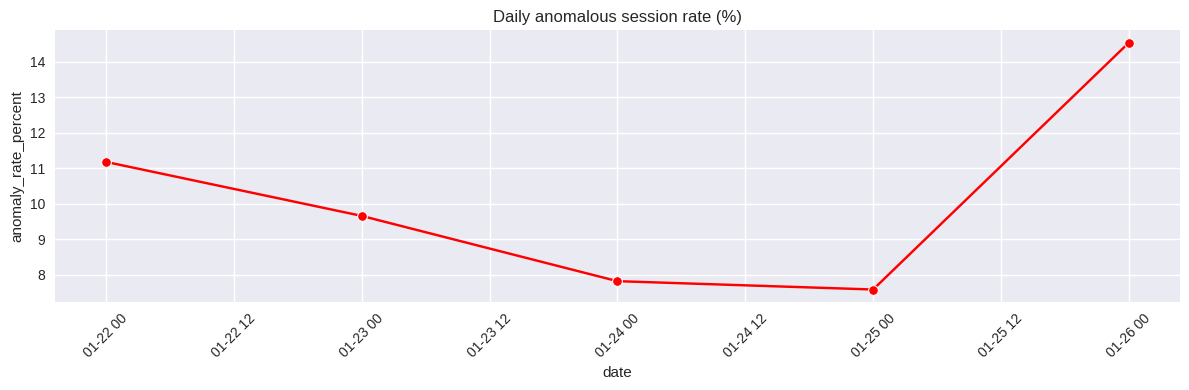

In [12]:
sessions["date"] = sessions["start_time"].dt.date

daily_anomalies = (
    sessions.groupby("date")["is_anomalous"]
    .mean()
    .mul(100)
    .rename("anomaly_rate_percent")
    .reset_index()
)

plt.figure(figsize=(12,4))
sns.lineplot(data=daily_anomalies, x="date", y="anomaly_rate_percent", marker="o", color="red")
plt.xticks(rotation=45)
plt.title("Daily anomalous session rate (%)")
plt.tight_layout()
plt.show()


In [13]:
top_anom_ips = (
    sessions[sessions["is_anomalous"] == 1]
    .groupby("user_id")
    .size()
    .rename("anomalous_sessions")
    .sort_values(ascending=False)
    .head(20)
)

top_anom_ips


user_id
37.32.29.198      42
95.82.39.94       32
37.9.113.152      32
5.45.207.88       29
216.244.66.248    29
178.131.221.63    24
66.249.93.32      22
37.255.249.243    21
37.255.213.16     21
66.249.83.93      21
217.219.76.102    21
37.9.113.36       20
66.249.83.92      20
66.102.9.32       19
66.102.9.39       19
66.249.66.94      19
37.9.113.126      19
66.249.93.39      19
66.102.9.143      18
66.249.83.91      18
Name: anomalous_sessions, dtype: int64

In [14]:
sessions.sort_values("anomaly_score").head(10)


,user_id,session_id,start_time,end_time,num_requests,unique_paths,num_errors,duration_sec,error_rate,requests_per_sec,start_hour,start_dayofweek,anomaly_score,is_anomalous,date
1905,104.222.32.91,5,2019-01-26 09:22:12+03:30,2019-01-26 19:55:59+03:30,306,235,11259,3335.76,0.267734,1.105872,9,5,-0.198406,1,2019-01-26
101674,40.77.167.79,2,2019-01-26 00:45:14+03:30,2019-01-26 05:08:14+03:30,306,235,23,3335.76,0.017504,0.083270,0,5,-0.197608,1,2019-01-26
309045,89.196.130.71,2,2019-01-26 03:17:10+03:30,2019-01-26 04:09:01+03:30,306,220,38,3111.00,0.107955,0.113147,3,5,-0.195595,1,2019-01-26
70485,2.191.96.86,8,2019-01-23 00:38:35+03:30,2019-01-23 02:04:13+03:30,306,114,217,3335.76,0.480088,0.087972,0,2,-0.194017,1,2019-01-23
231963,5.237.18.117,1,2019-01-22 05:24:00+03:30,2019-01-22 06:34:23+03:30,306,235,88,3335.76,0.077739,0.268056,5,1,-0.192404,1,2019-01-22
70481,2.191.96.86,4,2019-01-22 16:07:42+03:30,2019-01-22 17:03:08+03:30,306,235,158,3326.00,0.261589,0.181600,16,1,-0.190885,1,2019-01-22
70480,2.191.96.86,3,2019-01-22 13:49:35+03:30,2019-01-22 15:17:55+03:30,306,235,142,3335.76,0.233553,0.114717,13,1,-0.190686,1,2019-01-22
23630,17.58.102.43,2,2019-01-25 00:20:53+03:30,2019-01-26 18:23:58+03:30,306,235,235,3335.76,0.024426,0.063553,0,4,-0.190546,1,2019-01-25
326811,91.98.200.92,1,2019-01-26 00:37:28+03:30,2019-01-26 01:49:23+03:30,306,235,0,3335.76,0.000000,0.205098,0,5,-0.190546,1,2019-01-26
305946,86.55.249.206,2,2019-01-22 20:48:51+03:30,2019-01-22 22:05:20+03:30,306,235,100,3335.76,0.149701,0.145565,20,1,-0.190258,1,2019-01-22


In [15]:
# 7. Save model artifacts

import joblib, os

os.makedirs("models", exist_ok=True)
joblib.dump(pipe, "models/session_anomaly_iforest.pkl")
joblib.dump(feature_cols, "models/session_feature_cols.pkl")
print(os.listdir("models"))


['session_anomaly_iforest.pkl', 'session_feature_cols.pkl']


In [16]:
import os
print(os.listdir("models"))
print(os.listdir("."))  # show current folder


['session_anomaly_iforest.pkl', 'session_feature_cols.pkl']
['.virtual_documents', 'models']
